# Notebook 4 — Modèle préentraîné (TF-IDF + Dense)

Ce notebook présente le **modèle préentraîné style** pour comparer avec le modèle maison (Notebook 3).

**Différence clé avec le modèle custom :**
- Modèle custom : TextVectorization int → Embedding → BiLSTM (séquentiel)
- Modèle préentraîné : TextVectorization **TF-IDF** → Dense (bag of words pondéré)

Le TF-IDF est plus rapide et souvent plus efficace sur des textes courts et bruités comme les tickets support.

## 1. Imports et configuration

In [1]:
import os, sys, importlib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow :', tf.__version__)

TensorFlow : 2.21.0


## 2. Import des modules

In [2]:
import src.models.model_pretrained as _mp
import src.models.common as _cm
importlib.reload(_mp)
importlib.reload(_cm)

from src.models.model_pretrained import build_pretrained_style_model
from src.models.common import df_to_inputs
from src.data.clean_data import prepare_dataset
from src.data.build_features import make_split_for_target
from src.utils.config import MODELS_DIR, CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS

print('Modules chargés.')

Modules chargés.


## 3. Données — Priority

In [3]:
prepare_dataset()

X_train, X_test, y_train, y_test = make_split_for_target('priority_label')

# Labels en int + mapping textuel
y_train_enc = y_train.astype(int)
y_test_enc  = y_test.astype(int)

unique_vals  = sorted(set(y_train_enc))
priority_labels_all = ['Critical', 'High', 'Low', 'Medium']
class_names = [priority_labels_all[i] for i in unique_vals]
print('Classes :', class_names)

# Class weights
cw = compute_class_weight('balanced', classes=np.array(unique_vals), y=y_train_enc)
cw_dict = dict(zip(unique_vals, cw))
print('Class weights :', cw_dict)

Saved processed dataset to C:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\data\processed\tickets_ready.csv
Classes : ['Critical' 'High' 'Low' 'Medium']
Nb classes : 4
Classes : ['Critical', 'High', 'Low', 'Medium']
Class weights : {np.int64(0): np.float64(0.9945684086905461), np.int64(1): np.float64(1.0154376498800959), np.int64(2): np.float64(1.0265151515151516), np.int64(3): np.float64(0.9656499429874572)}


## 4. Inputs Keras + métadonnées

In [4]:
train_inputs = df_to_inputs(X_train)
test_inputs  = df_to_inputs(X_test)

categorical_vocabularies = {
    col: sorted(X_train[col].astype(str).unique().tolist())
    for col in CATEGORICAL_COLUMNS
}
numerical_means = {
    col: float(np.mean(X_train[col].astype('float32').values))
    for col in NUMERICAL_COLUMNS
}
numerical_vars = {
    col: float(np.var(X_train[col].astype('float32').values))
    for col in NUMERICAL_COLUMNS
}

print('Inputs prêts.')

Inputs prêts.


## 5. Construction du modèle préentraîné

Ce modèle utilise **TF-IDF** pour la branche texte au lieu d'un Embedding+BiLSTM.
Le TF-IDF pondère les mots par leur fréquence inverse dans le corpus, ce qui est
efficace pour des textes courts avec du vocabulaire métier spécifique.

In [5]:
model_pt, vectorizer_pt = build_pretrained_style_model(
    num_classes=len(class_names),
    categorical_vocabularies=categorical_vocabularies,
    numerical_means=numerical_means,
    numerical_vars=numerical_vars,
    text_corpus=X_train['text'].astype(str).tolist()
)

model_pt.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 1, 6124)   │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6124)      │          0 │ text_vectorizati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,568,000 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Gender     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Product Purchased   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Type         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Channel      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_1     │ (None, 4)         │          0 │ Customer          │
│ (StringLookup)      │                   │            │ Gender[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_2     │ (None, 43)        │          0 │ Product           │
│ (StringLookup)      │                   │            │ Purchased[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_3     │ (None, 6)         │          0 │ Ticket Type[0][0] │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_4     │ (None, 5)         │          0 │ Ticket            │
│ (StringLookup)      │                   │            │ Channel[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ string_lookup_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 43)        │          0 │ string_lookup_2[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,684,484 (6.43 MB)

 Trainable params: 1,683,460 (6.42 MB)

 Non-trainable params: 1,024 (4.00 KB)

## 6. Entraînement — Priority

In [6]:
callbacks_pt = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        min_lr=1e-6, verbose=1
    )
]

history_pt = model_pt.fit(
    train_inputs,
    y_train_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=cw_dict,
    callbacks=callbacks_pt,
    verbose=1
)

print(f'Meilleure val_accuracy : {max(history_pt.history["val_accuracy"]):.4f}')

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.2482 - loss: 1.7965 - val_accuracy: 0.2435 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.2662 - loss: 1.5595 - val_accuracy: 0.2524 - val_loss: 1.4039 - learning_rate: 0.0010
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.2718 - loss: 1.4761 - val_accuracy: 0.2465 - val_loss: 1.3978 - learning_rate: 0.0010
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3076 - loss: 1.3958 - val_accuracy: 0.2487 - val_loss: 1.3992 - learning_rate: 0.0010
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3532 - loss: 1.3504
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3544 - loss: 1.3471 - val_accuracy: 0.2590 - val_loss: 1.4110 - learning_rate: 0.0010
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4186 - loss: 1.

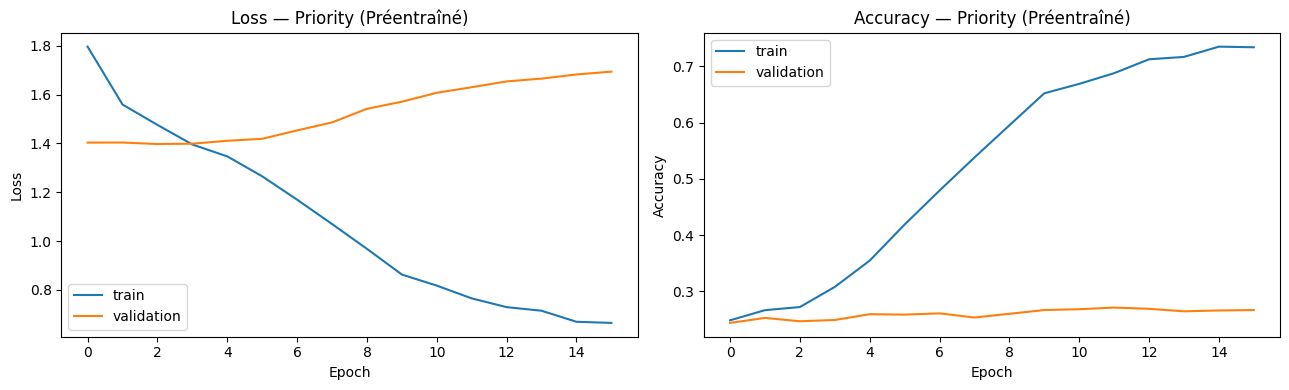

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_pt.history['loss'],     label='train')
axes[0].plot(history_pt.history['val_loss'], label='validation')
axes[0].set_title('Loss — Priority (Préentraîné)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_pt.history['accuracy'],     label='train')
axes[1].plot(history_pt.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy — Priority (Préentraîné)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/pretrained_priority_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Évaluation — Priority

In [8]:
test_loss_pt, test_acc_pt = model_pt.evaluate(test_inputs, y_test_enc, verbose=1)
print(f'\nTest loss     : {test_loss_pt:.4f}')
print(f'Test accuracy : {test_acc_pt:.4f}')

y_pred_pt = np.argmax(model_pt.predict(test_inputs, verbose=0), axis=1)

print('\nRapport de classification — Priority (Préentraîné)\n')
print(classification_report(y_test_enc, y_pred_pt, target_names=class_names))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2562 - loss: 1.6216

Test loss     : 1.6216
Test accuracy : 0.2562

Rapport de classification — Priority (Préentraîné)

              precision    recall  f1-score   support

    Critical       0.26      0.32      0.29       426
        High       0.26      0.23      0.24       417
         Low       0.24      0.20      0.22       413
      Medium       0.26      0.26      0.26       438

    accuracy                           0.26      1694
   macro avg       0.25      0.26      0.25      1694
weighted avg       0.26      0.26      0.25      1694



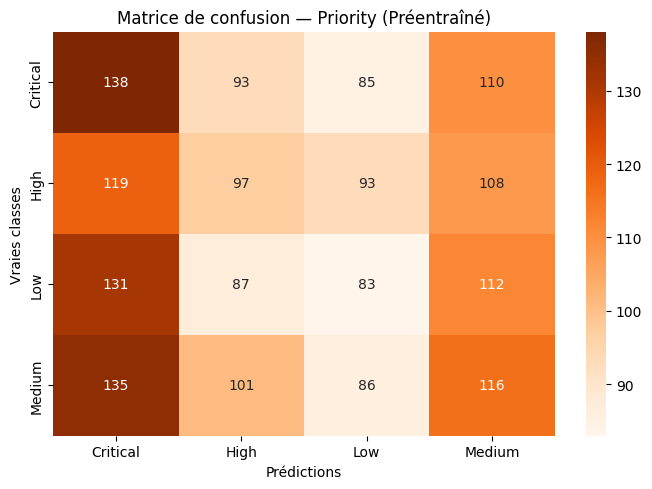

In [9]:
cm_pt = confusion_matrix(y_test_enc, y_pred_pt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de confusion — Priority (Préentraîné)')
plt.xlabel('Prédictions'); plt.ylabel('Vraies classes')
plt.tight_layout()
plt.savefig('../reports/figures/pretrained_priority_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
model_pt.save(MODELS_DIR / 'priority_pretrained.keras')
joblib.dump(class_names, MODELS_DIR / 'priority_class_names.pkl')
print('Modèle priority_pretrained.keras sauvegardé.')

Modèle priority_pretrained.keras sauvegardé.


---
## 8. Tâche de Routing — Préentraîné

La tâche de routing devrait donner de **meilleurs résultats** que la priority :
les labels (`support_technique`, `facturation`, etc.) sont directement liés
au vocabulaire présent dans le texte du ticket.

In [11]:
X_train_r, X_test_r, y_train_r, y_test_r = make_split_for_target('routing_label')

y_train_r_enc = y_train_r.astype(int)
y_test_r_enc  = y_test_r.astype(int)

unique_r = sorted(set(y_train_r_enc))
routing_labels_all = ['annulation','autre','facturation','information_produit','retour_produit','support_technique']
routing_class_names = [routing_labels_all[i] for i in unique_r]
print('Classes routing :', routing_class_names)

cw_r = compute_class_weight('balanced', classes=np.array(unique_r), y=y_train_r_enc)
cw_r_dict = dict(zip(unique_r, cw_r))

train_inputs_r = df_to_inputs(X_train_r)
test_inputs_r  = df_to_inputs(X_test_r)

cat_vocab_r = {col: sorted(X_train_r[col].astype(str).unique().tolist()) for col in CATEGORICAL_COLUMNS}
num_means_r = {col: float(np.mean(X_train_r[col].astype('float32').values)) for col in NUMERICAL_COLUMNS}
num_vars_r  = {col: float(np.var(X_train_r[col].astype('float32').values))  for col in NUMERICAL_COLUMNS}

Classes : ['annulation' 'facturation' 'information_produit' 'retour_produit'
 'support_technique']
Nb classes : 5
Classes routing : ['annulation', 'autre', 'facturation', 'information_produit', 'retour_produit']


In [12]:
model_pt_r, vec_pt_r = build_pretrained_style_model(
    num_classes=len(routing_class_names),
    categorical_vocabularies=cat_vocab_r,
    numerical_means=num_means_r,
    numerical_vars=num_vars_r,
    text_corpus=X_train_r['text'].astype(str).tolist()
)

callbacks_r = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )
]

history_pt_r = model_pt_r.fit(
    train_inputs_r,
    y_train_r_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=cw_r_dict,
    callbacks=callbacks_r,
    verbose=1
)

print(f'Meilleure val_accuracy routing : {max(history_pt_r.history["val_accuracy"]):.4f}')

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.3502 - loss: 1.7053 - val_accuracy: 0.9911 - val_loss: 0.7832 - learning_rate: 0.0010
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7775 - loss: 0.6221 - val_accuracy: 1.0000 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9716 - loss: 0.1106 - val_accuracy: 1.0000 - val_loss: 9.7295e-04 - learning_rate: 0.0010
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9902 - loss: 0.0378 - val_accuracy: 1.0000 - val_loss: 1.1583e-04 - learning_rate: 0.0010
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9954 - loss: 0.0220 - val_accuracy: 1.0000 - val_loss: 3.2676e-05 - learning_rate: 0.0010
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9958 - loss: 0.0149 - val_accuracy: 1.0000 - val_loss: 1.1009e-05 - learning_rate: 0.0010
Epoch 6: early stopping
Restoring model weights from the end of t

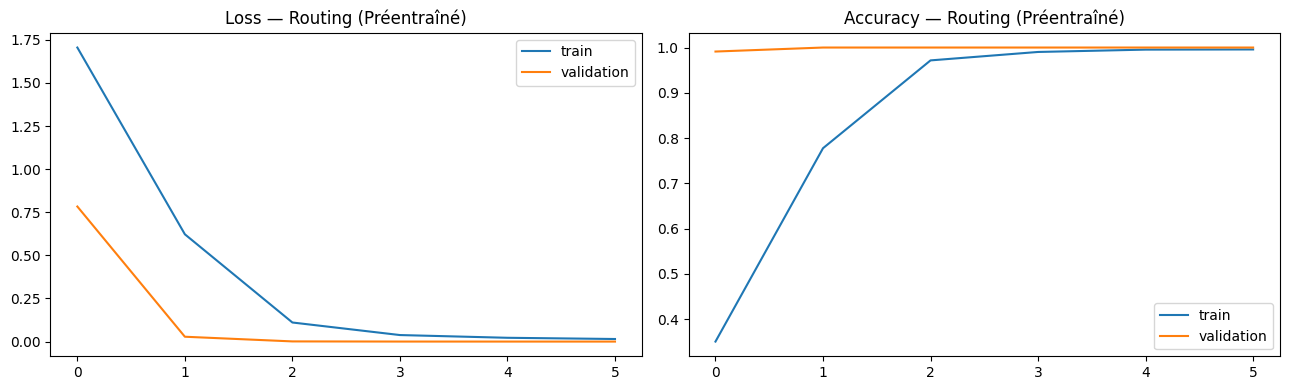

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_pt_r.history['loss'],     label='train')
axes[0].plot(history_pt_r.history['val_loss'], label='validation')
axes[0].set_title('Loss — Routing (Préentraîné)'); axes[0].legend()
axes[1].plot(history_pt_r.history['accuracy'],     label='train')
axes[1].plot(history_pt_r.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy — Routing (Préentraîné)'); axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/figures/pretrained_routing_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
test_loss_r, test_acc_r = model_pt_r.evaluate(test_inputs_r, y_test_r_enc, verbose=1)
print(f'\nTest loss     : {test_loss_r:.4f}')
print(f'Test accuracy : {test_acc_r:.4f}')

y_pred_pt_r = np.argmax(model_pt_r.predict(test_inputs_r, verbose=0), axis=1)

print('\nRapport de classification — Routing (Préentraîné)\n')
print(classification_report(y_test_r_enc, y_pred_pt_r, target_names=routing_class_names))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0272

Test loss     : 0.0272
Test accuracy : 1.0000

Rapport de classification — Routing (Préentraîné)

                     precision    recall  f1-score   support

         annulation       1.00      1.00      1.00       339
              autre       1.00      1.00      1.00       327
        facturation       1.00      1.00      1.00       328
information_produit       1.00      1.00      1.00       351
     retour_produit       1.00      1.00      1.00       349

           accuracy                           1.00      1694
          macro avg       1.00      1.00      1.00      1694
       weighted avg       1.00      1.00      1.00      1694



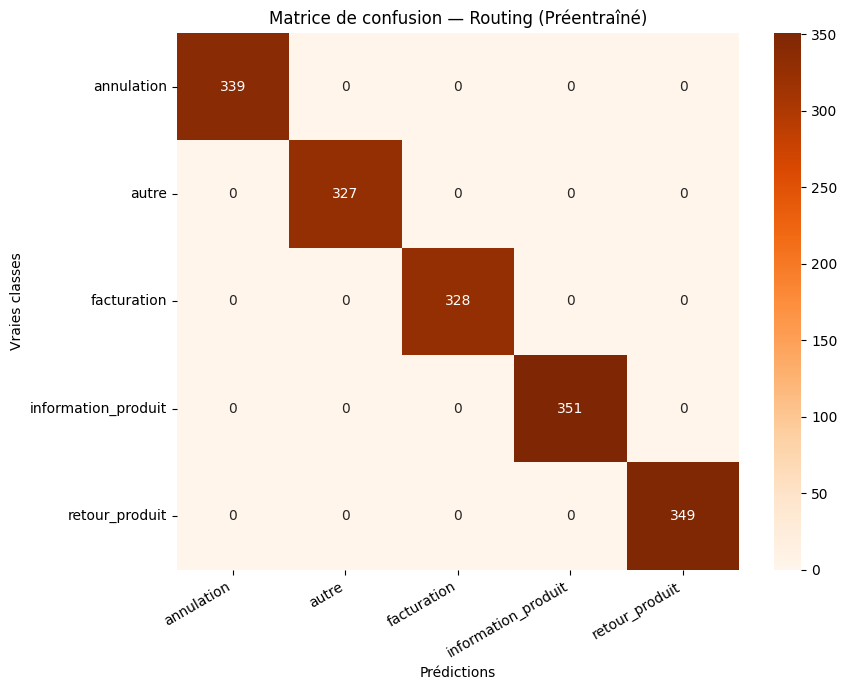

In [15]:
cm_r = confusion_matrix(y_test_r_enc, y_pred_pt_r)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Oranges',
            xticklabels=routing_class_names, yticklabels=routing_class_names)
plt.title('Matrice de confusion — Routing (Préentraîné)')
plt.xlabel('Prédictions'); plt.ylabel('Vraies classes')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('../reports/figures/pretrained_routing_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
model_pt_r.save(MODELS_DIR / 'routing_pretrained.keras')
joblib.dump(routing_class_names, MODELS_DIR / 'routing_class_names.pkl')
print('Modèle routing_pretrained.keras sauvegardé.')

Modèle routing_pretrained.keras sauvegardé.


## 9. Conclusion

Le modèle préentraîné style TF-IDF a été entraîné sur les deux tâches.

**Points clés :**
- TF-IDF est plus rapide que BiLSTM et souvent plus efficace sur des textes courts ;
- La tâche routing bénéficie d'un signal textuel plus fort que priority ;
- Les résultats seront comparés dans le **Notebook 5** avec le modèle maison.

| Tâche | Modèle | Metric clé |
|---|---|---|
| Priority | Préentraîné TF-IDF | test_accuracy |
| Routing | Préentraîné TF-IDF | test_accuracy |